In [9]:
import numpy as np
import torch
from scipy.io import loadmat
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from pyriemann.classification import MDM

import umap
from scipy.linalg import logm
from tqdm import tqdm

from pathlib import Path
import os

notebook_dir = Path().absolute()
if notebook_dir.name == 'examples':
    os.chdir(notebook_dir.parent)

from src.metrics import compute_static_fc, fisher_batch_average
%matplotlib inline

In [10]:
N_SUBJECTS = 200
abide = datasets.fetch_abide_pcp(n_subjects=N_SUBJECTS, data_dir="data/abide", DX_GROUP=[1, 2], verbose=0)
X_files = abide.func_preproc
y_raw = np.array(abide.phenotypic["DX_GROUP"])  # 1=autism, 2=control
y = (y_raw == 1).astype(int)  # 1=autism, 0=control
labels = np.array(["control" if yi == 0 else "autism" for yi in y])

print(np.unique(labels, return_counts=True))

ConnectionError: HTTPSConnectionPool(host='s3.amazonaws.com', port=443): Read timed out.

In [ ]:
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, data_dir="data/nilearn")
masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize="zscore_sample",
    memory="data/nilearn_cache",
    verbose=0,
)

timeseries_list = []
valid_idx = []
for i, fpath in tqdm(enumerate(X_files), total=len(X_files)):
    try:
        ts = masker.fit_transform(fpath)  # (T, n_rois)
        if ts.shape[0] > 10 and ts.shape[1] > 5:
            timeseries_list.append(ts)
            valid_idx.append(i)
    except Exception as e:
        print(f"  Skipping subject {i}: {e}")

y = y[valid_idx]
labels = labels[valid_idx]
n_subjects = len(timeseries_list)
print(f"Valid subjects: {n_subjects}")

# Compute FC per subject using project's compute_static_fc
print("Computing functional connectivity matrices...")
fc_matrices = []
for ts in tqdm(timeseries_list, total=len(timeseries_list)):
    ts_tensor = torch.tensor(ts.T, dtype=torch.float32).unsqueeze(0)  # (1, n_rois, T)
    fc = compute_static_fc(ts_tensor).squeeze(0).numpy()  # (n_rois, n_rois)
    fc_matrices.append(fc)

fc_matrices = np.array(fc_matrices)  # (n_subjects, n_rois, n_rois)
n_rois = fc_matrices.shape[1]
print(f"FC matrices shape: {fc_matrices.shape}")

# Ensure SPD: regularize diagonal
for i in range(n_subjects):
    fc_matrices[i] = (fc_matrices[i] + fc_matrices[i].T) / 2
    eigvals = np.linalg.eigvalsh(fc_matrices[i])
    if eigvals.min() <= 0:
        fc_matrices[i] += (abs(eigvals.min()) + 1e-4) * np.eye(n_rois)


[fetch_atlas_schaefer_2018] Dataset found in data/nilearn/schaefer_2018

100%|██████████| 50/50 [07:27<00:00,  8.95s/it]


Valid subjects: 50
Computing functional connectivity matrices...


100%|██████████| 50/50 [00:00<00:00, 86.89it/s]


FC matrices shape: (50, 100, 100)


In [ ]:
def upper_tri_features(matrices):
    """Flatten upper triangle of each matrix into a feature vector."""
    idx = np.triu_indices(matrices.shape[1], k=1)
    return np.array([m[idx] for m in matrices])


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}


def evaluate(name, X_feat, y, clf=None):
    if clf is None:
        clf = SVC(kernel="linear", C=1.0)
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    scores = cross_val_score(pipe, X_feat, y, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"  {name}: {scores.mean():.3f} +/- {scores.std():.3f}")


# --- Level 1: Euclidean / Vectorization ---
print("\n" + "=" * 60)
print("LEVEL 1: Euclidean / Vectorization")
print("=" * 60)
X_vec = upper_tri_features(fc_matrices)
print(f"Feature vector length: {X_vec.shape[1]}")

evaluate("L1: SVM (linear)", X_vec, y, SVC(kernel="linear", C=1.0))
evaluate("L1: SVM (rbf)", X_vec, y, SVC(kernel="rbf", C=1.0))
evaluate("L1: Random Forest", X_vec, y, RandomForestClassifier(n_estimators=200, random_state=42))
evaluate("L1: Logistic Regression", X_vec, y, LogisticRegression(max_iter=5000, C=1.0))

# --- Level 2: Log-Euclidean Framework ---
print("\n" + "=" * 60)
print("LEVEL 2: Log-Euclidean Framework")
print("=" * 60)
print("Computing matrix logarithms...")

fc_log = np.array([logm(fc) for fc in fc_matrices])
# logm can return complex with tiny imaginary parts; take real
fc_log = np.real(fc_log)
X_log_vec = upper_tri_features(fc_log)
print(f"Log-Euclidean feature vector length: {X_log_vec.shape[1]}")

evaluate("L2: Log-Euclidean SVM (linear)", X_log_vec, y, SVC(kernel="linear", C=1.0))
evaluate("L2: Log-Euclidean SVM (rbf)", X_log_vec, y, SVC(kernel="rbf", C=1.0))
evaluate("L2: Log-Euclidean LogReg", X_log_vec, y, LogisticRegression(max_iter=5000, C=1.0))

# --- Level 2b: Tangent Space Mapping (pyriemann) ---
print("\n" + "=" * 60)
print("LEVEL 2b: Tangent Space Mapping (pyriemann)")
print("=" * 60)

ts_mapper = TangentSpace(metric="riemann")
X_tangent = ts_mapper.fit_transform(fc_matrices)
print(f"Tangent space feature vector length: {X_tangent.shape[1]}")

evaluate("L2b: TSM + SVM (linear)", X_tangent, y, SVC(kernel="linear", C=1.0))
evaluate("L2b: TSM + SVM (rbf)", X_tangent, y, SVC(kernel="rbf", C=1.0))
evaluate("L2b: TSM + LogReg", X_tangent, y, LogisticRegression(max_iter=5000, C=1.0))

# --- Level 3: Riemannian MDM ---
print("\n" + "=" * 60)
print("LEVEL 3: Riemannian MDM (Minimum Distance to Mean)")
print("=" * 60)

mdm = MDM(metric=dict(mean="riemann", distance="riemann"))
scores_mdm = cross_val_score(mdm, fc_matrices, y, cv=cv, scoring="accuracy")
results["L3: Riemannian MDM"] = scores_mdm
print(f"  L3: Riemannian MDM: {scores_mdm.mean():.3f} +/- {scores_mdm.std():.3f}")


LEVEL 1: Euclidean / Vectorization
Feature vector length: 4950
  L1: SVM (linear): 0.640 +/- 0.136
  L1: SVM (rbf): 0.480 +/- 0.075
  L1: Random Forest: 0.520 +/- 0.098
  L1: Logistic Regression: 0.640 +/- 0.136

LEVEL 2: Log-Euclidean Framework
Computing matrix logarithms...


/home/dani/projects/neuroscience_control/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 1.7124191344919382e-06
  return f(*arrays, *other_args, **kwargs)
/home/dani/projects/neuroscience_control/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 1.3175880440030596e-06
  return f(*arrays, *other_args, **kwargs)
/home/dani/projects/neuroscience_control/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 1.3797812243865337e-06
  return f(*arrays, *other_args, **kwargs)
/home/dani/projects/neuroscience_control/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 1.9059186797676375e-06
  return f(*arrays, *other_args, **kwargs)
/home/dani/projects/neuroscience_control/.venv/lib/python3.13/site-p

Log-Euclidean feature vector length: 4950
  L2: Log-Euclidean SVM (linear): 0.660 +/- 0.102
  L2: Log-Euclidean SVM (rbf): 0.560 +/- 0.120
  L2: Log-Euclidean LogReg: 0.640 +/- 0.136

LEVEL 2b: Tangent Space Mapping (pyriemann)
Tangent space feature vector length: 5050
  L2b: TSM + SVM (linear): 0.620 +/- 0.147
  L2b: TSM + SVM (rbf): 0.540 +/- 0.080
  L2b: TSM + LogReg: 0.600 +/- 0.179

LEVEL 3: Riemannian MDM (Minimum Distance to Mean)
  L3: Riemannian MDM: 0.560 +/- 0.136



CLASSIFICATION RESULTS SUMMARY


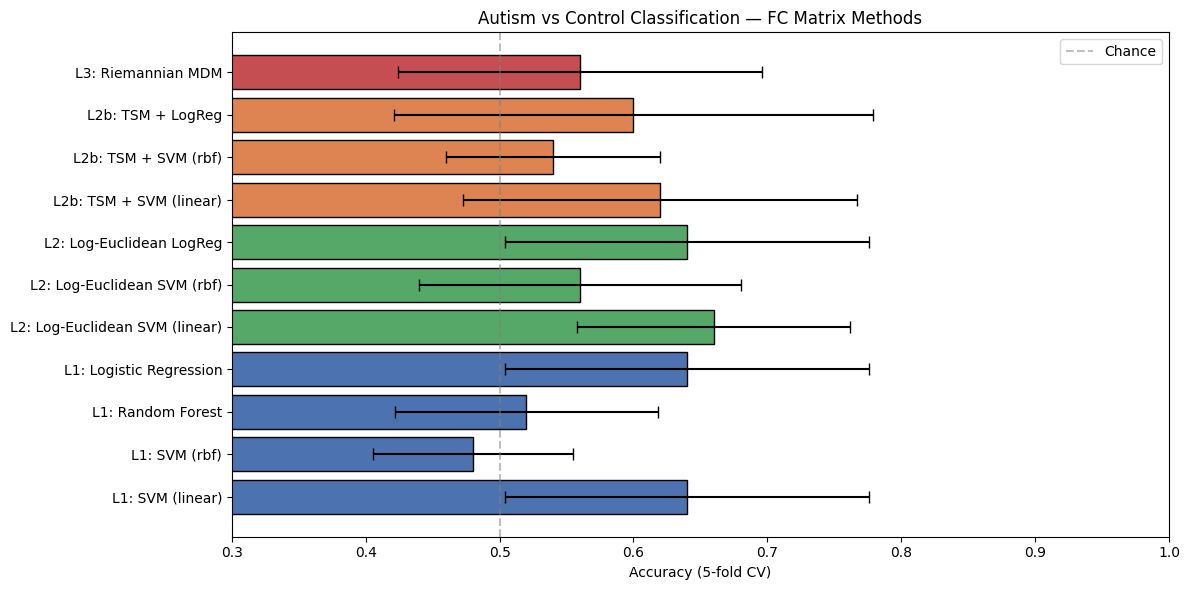

Saved: examples/classification_results.png


In [ ]:
# --------------------------------------------------------------------------
# 4. Summary bar plot
# --------------------------------------------------------------------------
print("\n" + "=" * 60)
print("CLASSIFICATION RESULTS SUMMARY")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 6))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds = [results[n].std() for n in names]

colors = []
for n in names:
    if n.startswith("L1"):
        colors.append("#4c72b0")
    elif n.startswith("L2b"):
        colors.append("#dd8452")
    elif n.startswith("L2"):
        colors.append("#55a868")
    else:
        colors.append("#c44e52")

bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor="black", capsize=4)
ax.set_xlabel("Accuracy (5-fold CV)")
ax.set_title("Autism vs Control Classification — FC Matrix Methods")
ax.set_xlim(0.3, 1.0)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance")
ax.legend()
plt.tight_layout()
plt.savefig("examples/classification_results.png", dpi=150, bbox_inches="tight")
from pathlib import Path
Path("paper/images_png").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_png/classification_results.png", bbox_inches="tight", dpi=200)
Path("paper/images_svg").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_svg/classification_results.svg", bbox_inches="tight")
plt.show()
print("Saved: examples/classification_results.png")


2D VISUALIZATIONS


/home/dani/projects/neuroscience_control/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


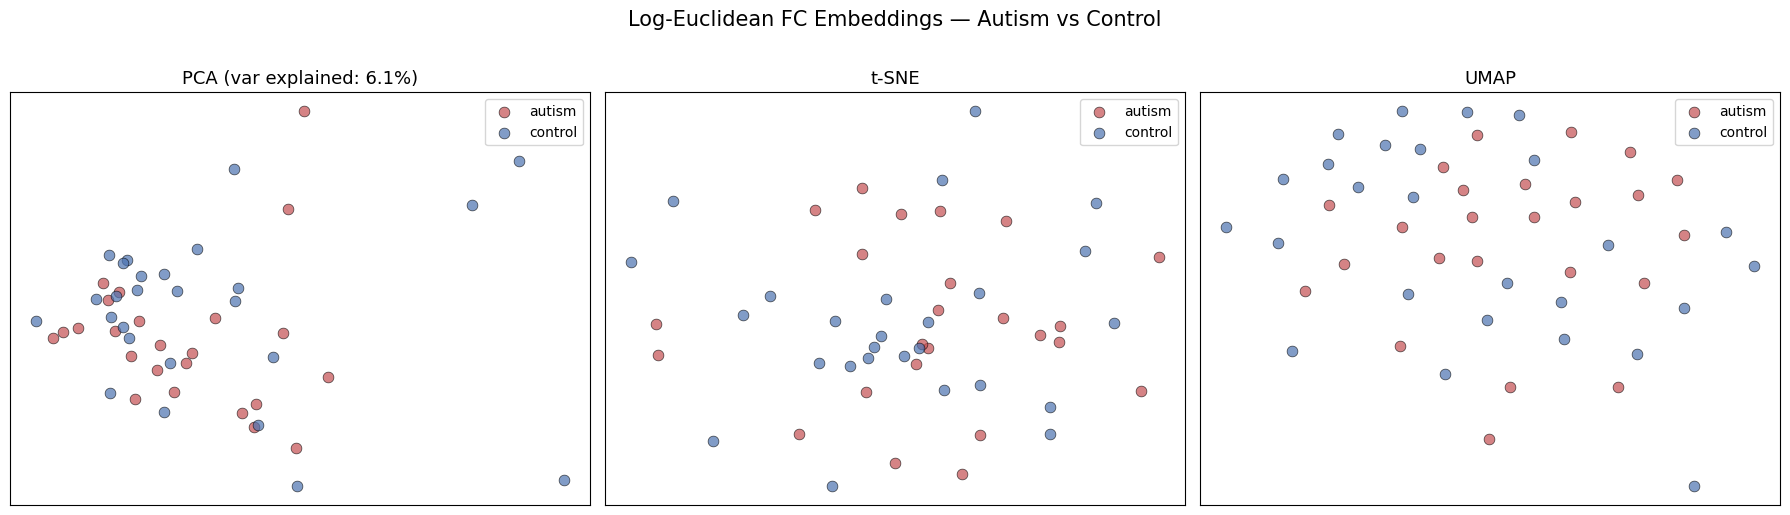

Saved: examples/classification_embeddings.png


In [ ]:
print("\n" + "=" * 60)
print("2D VISUALIZATIONS")
print("=" * 60)

# Use Log-Euclidean features for visualization (Level 2 — best balance)
X_vis = X_log_vec.copy()
X_vis_scaled = StandardScaler().fit_transform(X_vis)

# --- PCA ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vis_scaled)

# --- t-SNE ---
perplexity = min(30, n_subjects - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_vis_scaled)

# --- UMAP ---
n_neighbors = min(15, n_subjects - 1)
reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, random_state=42)
X_umap = reducer.fit_transform(X_vis_scaled)

# Plot all three
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

color_map = {"autism": "#c44e52", "control": "#4c72b0"}

for ax, X_2d, title in zip(
    axes,
    [X_pca, X_tsne, X_umap],
    [
        f"PCA (var explained: {pca.explained_variance_ratio_.sum():.1%})",
        "t-SNE",
        "UMAP",
    ],
):
    for label, color in color_map.items():
        mask = labels == label
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=label, alpha=0.7, s=60, edgecolors="k", linewidths=0.5)
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Log-Euclidean FC Embeddings — Autism vs Control", fontsize=15, y=1.02)
plt.tight_layout()
# plt.savefig("examples/classification_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: examples/classification_embeddings.png")

/home/dani/projects/neuroscience_control/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


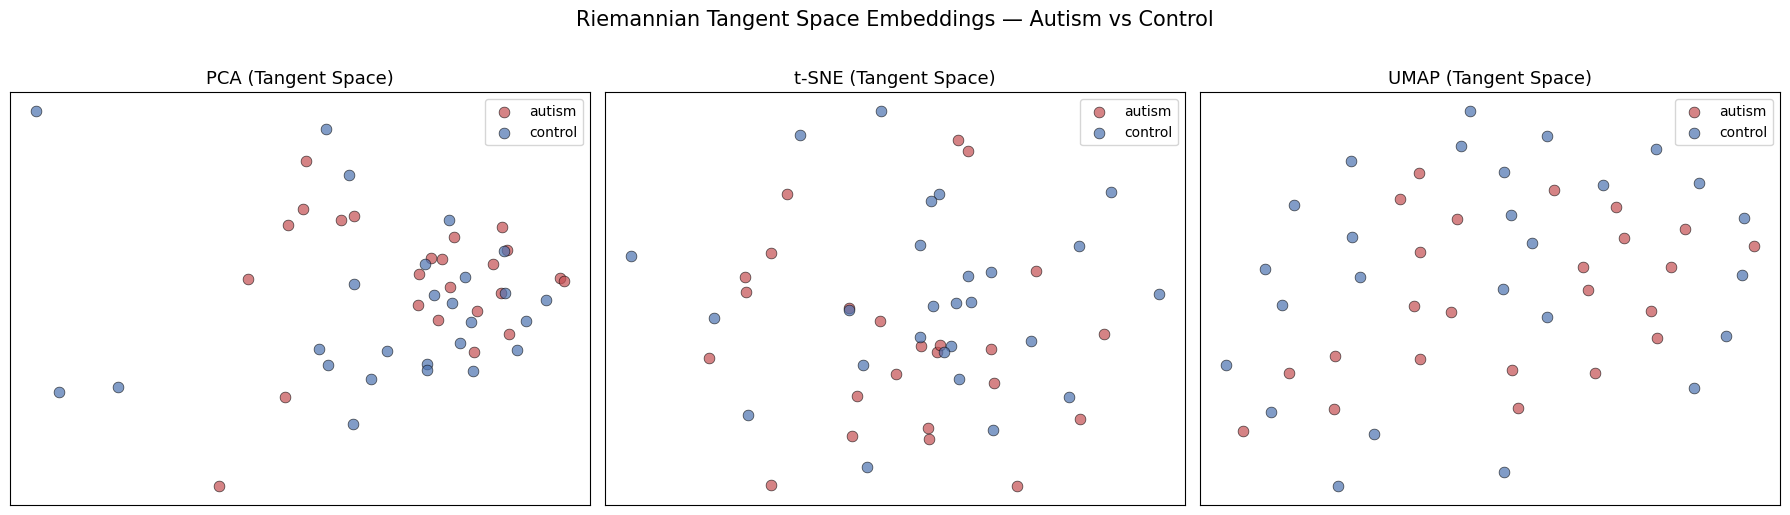

Saved: examples/classification_embeddings_tangent.png


In [ ]:
# --------------------------------------------------------------------------
# 6. Also visualize Tangent Space features
# --------------------------------------------------------------------------
X_ts_scaled = StandardScaler().fit_transform(X_tangent)

X_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_ts_scaled)
X_tsne2 = TSNE(n_components=2, perplexity=perplexity, random_state=42, init="pca").fit_transform(X_ts_scaled)
X_umap2 = umap.UMAP(n_components=2, n_neighbors=n_neighbors, random_state=42).fit_transform(X_ts_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, X_2d, title in zip(
    axes,
    [X_pca2, X_tsne2, X_umap2],
    ["PCA (Tangent Space)", "t-SNE (Tangent Space)", "UMAP (Tangent Space)"],
):
    for label, color in color_map.items():
        mask = labels == label
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=label, alpha=0.7, s=60, edgecolors="k", linewidths=0.5)
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Riemannian Tangent Space Embeddings — Autism vs Control", fontsize=15, y=1.02)
plt.tight_layout()
# plt.savefig("examples/classification_embeddings_tangent.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: examples/classification_embeddings_tangent.png")
